<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/platt.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [432]:
#############################################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)                                  #
# E-mail: wgomez@cinvestav.mx                                               #
# Curso:  Análisis de datos                                                 #
# Tópico: Calibración de Platt                                              #
# Referencia:                                                               #
#   Platt, John (1999). "Probabilistic outputs for support vector machines  #
#   and comparisons to regularized likelihood methods". Advances in large   #
#   margin classifiers. 10(3): 61-74.                                       #
#############################################################################

Carga bibliotecas necesarias

In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [434]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [435]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [436]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Función para la calibración de Platt basada en el código del artículo.

In [437]:
def log_(n):
    # Protección para valores <= 0
    result = -200.0*np.ones_like(n, dtype=float)
    l = np.log(n, where=n > 0, out=result)
    return l

def platt_calibrate(out, target):
    prior1 = np.sum(target)
    prior0 = np.sum(np.logical_not(target))
    N = prior1 + prior0
    A = 0.0
    B = (prior0 + 1.0) / (prior1 + 1.0)
    hiTarget = (prior1 + 1.0) / (prior1 + 2.0)
    loTarget = 1.0 / (prior0 + 2.0)
    lambda_val = 1e-3
    olderr = 1e300
    pp = np.ones(N) * ((prior1 + 1.0) / (prior0 + prior1 + 2.0))
    count = 0
    t = (target * hiTarget) + (np.logical_not(target) * loTarget)
    for it in range(100):
        d1 = pp - t
        d2 = pp * (1.0 - pp)
        a = np.sum(out * out * d2)
        b = np.sum(d2)
        c = np.sum(out * d2)
        d = np.sum(out * d1)
        e = np.sum(d1)
        if (abs(d) < 1e-9) and (abs(e) < 1e-9):
            break
        oldA = A
        oldB = B
        while True:
            det_ = (a + lambda_val) * (b + lambda_val) - c * c
            if det_ == 0:
                lambda_val = lambda_val * 10
                continue
            A = oldA + ((b + lambda_val) * d - c * e) / det_
            B = oldB + ((a + lambda_val) * e - c * d) / det_
            # P(y=1|f) = 1 / (1 + exp(Af + B))
            lin = np.array([out * A + B], dtype=np.float128)
            pp = 1.0 / (1.0 + np.exp(lin))
            err = -np.sum(t * log_(pp) + (1.0 - t) * log_(1.0 - pp))
            if err < olderr * (1.0 + 1e-7):
                lambda_val = lambda_val * 0.1
                break
            lambda_val = lambda_val * 10
            if lambda_val >= 1e6:
                break
        dif = err - olderr
        scale = 0.5 * (err + olderr + 1.0)
        if (dif > (-1e-3) * scale) and (dif < (1e-7) * scale):
            count = count + 1
        else:
            count = 0
        olderr = err
        if count == 3:
            break
    return A, B

Entrenamiento del clasificador binario basado en LDA

In [438]:
def lda(X, Y, i):
    ci = (Y == i).flatten() # Muestras de la i-esima clase
    cj = (Y != i).flatten() # Muestras del resto de las clases
    Cn = X[cj, :]
    Cp = X[ci, :]
    MUn = np.mean(Cn, axis=0, keepdims=True)
    MUp = np.mean(Cp, axis=0, keepdims=True)
    Cn = Cn - MUn
    Cp = Cp - MUp
    SW = (1 / (X.shape[0] - 2)) * ((Cn.T @ Cn) + (Cp.T @ Cp)) # Matriz de dispersion intraclase
    W = np.linalg.pinv(SW) @ (MUp - MUn).T # Pesos
    b = -0.5 * (MUp + MUn) # Bias
    return W, b

OVA con calibración de Platt

In [439]:
# Entrenamiento
def ova_train(X, Y):
    d = X.shape[1] # Número de variables
    c = len(np.unique(Y)) # Número de clases
    W = np.zeros((d, c))
    b = np.zeros((c, d))
    alpha = np.zeros(c) # Parámetros de la calibración
    beta = np.zeros(c)
    for i in range(c):
        Wi, bi = lda(X, Y, i) # Entrena i-ésima clase vs. el resto
        W[:, i] = Wi.flatten() # Salva vector de pesos
        b[i, :] = bi.flatten() # Salva el bias
        gx = (X + bi) @ Wi # Predice salidas lineales
        alpha[i], beta[i] = platt_calibrate(gx, Y == i) # Calcula parámetros de la calibración
    return W, b, alpha, beta

# Predicción
def ova_predict(X, W, b, alpha, beta):
    c = b.shape[0] # Número de clases
    n = X.shape[0] # Número de muestras de prueba
    r = np.zeros((n, c)) # Vector de respuestas para cada muestra de prueba
    for i in range(c):
        gx = (X + b[i, :]) @ W[:, i] # Evalua el i-ésimo clasificador lineal
        r[:, i] = 1.0 / (1.0 + np.exp(alpha[i] * gx + beta[i])) # Salida calibrada
    #r = r/np.sum(r, axis=1, keepdims=True) # Normaliza
    #print(np.round(r, 2))
    Y_pred = np.argmax(r, axis=1) # Clasifica por máxima confianza
    Y_pred = Y_pred.reshape(-1, 1) # Asegurar vector columna
    return Y_pred

Entrenamiento y clasificación con OVA

In [440]:
# Entrena los c clasificadores de OVA
W, b, alpha, beta = ova_train(X_train, Y_train)
# Clasifica
Y_pred = ova_predict(X_test, W, b, alpha, beta)

Visualiza matriz de confusión

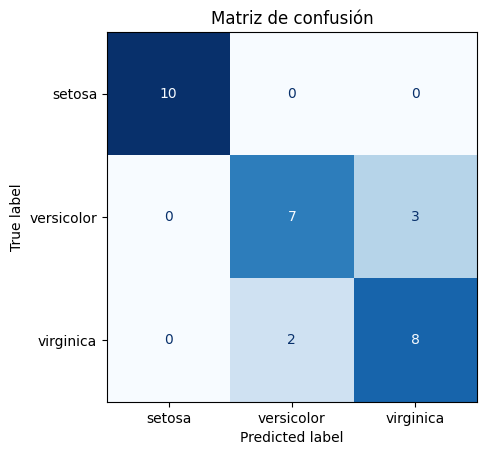

Exactitud: 0.833


In [441]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")